# Customer Churn Prediction — Model Development

## Objective

The objective of this notebook is to develop and evaluate machine learning models for predicting customer churn.

The analysis starts with a simple baseline and progressively evaluates more sophisticated classification models. Model performance will be assessed using metrics appropriate for an imbalanced classification problem, with particular attention to the identification of customers at risk of churn.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## 1. Initial Data Preparation

The dataset is loaded and prepared for model development. The target variable `Churn` is converted into a binary variable, where `1` represents churn and `0` represents non-churn.

The data is then divided into training and test sets using stratified sampling to preserve the original churn distribution. The test set is reserved for the final evaluation of the selected model.

In [87]:
df = pd.read_csv(
    "../data/raw/sales.csv"
)

In [88]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [89]:
customer_ids = df["customerID"]

X = df.drop(columns=["customerID", "Churn"])

y = df["Churn"]

In [90]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [92]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

### Preprocessing Pipeline

The preprocessing strategy developed in the previous notebook is reproduced here and integrated directly into each machine learning pipeline.

Numerical features are standardized, categorical features are one-hot encoded, and `SeniorCitizen` is retained as an already binary numerical variable. Integrating preprocessing into the pipeline ensures that transformations are fitted exclusively on the appropriate training data during cross-validation, preventing data leakage.

In [93]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        ), categorical_features)
    ],
    remainder="passthrough"
)

## 2. Baseline Model

Before training predictive models, a simple baseline classifier is evaluated to establish a minimum reference point.

The baseline always predicts the majority class (`No Churn`). Since approximately 73% of customers do not churn, accuracy alone can be misleading in this problem.

In [94]:
from sklearn.dummy import DummyClassifier

In [95]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy))
print("F1 Score:", f1_score(y_test, y_pred_dummy))

Accuracy: 0.7345635202271115
Balanced Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [98]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_dummy)

array([[1035,    0],
       [ 374,    0]])

### Baseline Interpretation

Although the baseline achieves approximately 73.5% accuracy, it fails to identify any customers who actually churn.

Its recall and F1 score are therefore zero, while the balanced accuracy of 0.50 indicates no meaningful ability to distinguish between churners and non-churners.

This confirms that accuracy should not be used as the primary evaluation metric for this imbalanced classification problem.

## 3. Logistic Regression

Logistic Regression is used as the first predictive model. It provides a relatively simple and interpretable benchmark before evaluating more complex non-linear models.

Model performance is evaluated using stratified 5-fold cross-validation on the training data.

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [100]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [101]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [102]:
from sklearn.model_selection import cross_val_score

cv_scores_logistic = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC per fold:", cv_scores_logistic)
print("Mean ROC-AUC:", cv_scores_logistic.mean())
print("Standard deviation:", cv_scores_logistic.std())

ROC-AUC per fold: [0.8479715  0.82511552 0.84196113 0.86298329 0.85299649]
Mean ROC-AUC: 0.8462055854048229
Standard deviation: 0.012597876673947479


In [103]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results_logistic = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [104]:
for metric in scoring:
    scores = cv_results_logistic[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

roc_auc: 0.846 ± 0.013
average_precision: 0.662 ± 0.019
balanced_accuracy: 0.720 ± 0.020
precision: 0.653 ± 0.027
recall: 0.544 ± 0.041
f1: 0.593 ± 0.030


### Logistic Regression Results

Logistic Regression provides a strong initial predictive baseline, achieving a mean ROC-AUC of 0.846 and an Average Precision of 0.662 across the five cross-validation folds.

At the default classification threshold, the model achieves higher precision than recall, indicating that its churn predictions are relatively selective but that a substantial proportion of churners remain undetected.

The relatively small variation across folds suggests that the model performance is reasonably stable.

## 4. Class Imbalance Strategy

Because churn represents the minority class, a class-weighted Logistic Regression is evaluated.

Using `class_weight="balanced"` increases the importance assigned to errors involving the minority churn class. This is expected to increase churn detection (recall), potentially at the cost of generating more false positives and therefore reducing precision.

In [105]:
logistic_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

cv_results_logistic_balanced = cross_validate(
    logistic_balanced,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results_logistic_balanced[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

roc_auc: 0.846 ± 0.012
average_precision: 0.660 ± 0.020
balanced_accuracy: 0.766 ± 0.020
precision: 0.518 ± 0.019
recall: 0.803 ± 0.036
f1: 0.629 ± 0.022


### Balanced Logistic Regression Results

Applying balanced class weights substantially increases recall from approximately 0.54 to 0.80, meaning that the model identifies a much larger proportion of customers who churn.

However, precision decreases from approximately 0.65 to 0.52, illustrating the expected trade-off between detecting more churners and generating additional false-positive alerts.

The ranking performance remains almost unchanged, with ROC-AUC and Average Precision similar to the standard Logistic Regression model.

### 4.1 Logistic Regression Hyperparameter Tuning

A small hyperparameter search is performed to determine whether different regularization strengths or class-weighting strategies improve the model.

Average Precision is used as the optimization metric because it evaluates the precision-recall trade-off across classification thresholds and is particularly useful for imbalanced classification problems.

In [106]:
from sklearn.model_selection import GridSearchCV

param_grid_logistic = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

grid_logistic = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_logistic,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train);

In [107]:
print("Best parameters:", grid_logistic.best_params_)
print("Best CV Average Precision:", grid_logistic.best_score_)

Best parameters: {'classifier__C': 1, 'classifier__class_weight': None}
Best CV Average Precision: 0.6615202290620502


### Tuning Results

The hyperparameter search selects `C=1` and no class weighting, which correspond to the standard Logistic Regression configuration.

The resulting Average Precision is essentially unchanged from the original model. Therefore, the search does not provide a meaningful improvement over the initial Logistic Regression baseline.

## 5. Random Forest

Random Forest is evaluated as a non-linear alternative to Logistic Regression.

By combining multiple decision trees trained on different samples and feature subsets, the model can capture more complex relationships and interactions between customer characteristics.

The same cross-validation strategy and evaluation metrics are used to ensure a consistent comparison between models.

In [108]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [109]:
cv_results_rf = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results_rf[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

roc_auc: 0.823 ± 0.015
average_precision: 0.615 ± 0.030
balanced_accuracy: 0.687 ± 0.015
precision: 0.627 ± 0.030
recall: 0.476 ± 0.024
f1: 0.541 ± 0.024


### Random Forest Results

Random Forest achieves lower ROC-AUC, Average Precision, balanced accuracy, recall, and F1 score than Logistic Regression.

Therefore, the initial Random Forest configuration does not provide an improvement for this churn prediction problem and is not prioritized for further optimization.

## 6. XGBoost

XGBoost is evaluated as a gradient boosting model capable of capturing complex non-linear relationships and feature interactions.

Unlike Random Forest, where trees are largely constructed independently, gradient boosting builds trees sequentially, with each stage attempting to improve the errors of the existing ensemble.

In [110]:
from xgboost import XGBClassifier

xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [111]:
cv_results_xgb = cross_validate(
    xgboost_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results_xgb[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

roc_auc: 0.847 ± 0.012
average_precision: 0.669 ± 0.022
balanced_accuracy: 0.716 ± 0.013
precision: 0.669 ± 0.025
recall: 0.526 ± 0.023
f1: 0.589 ± 0.022


### Initial XGBoost Results

The initial XGBoost model achieves competitive performance, with a mean ROC-AUC of 0.847 and Average Precision of 0.669.

Its ranking performance slightly exceeds the initial Logistic Regression model, making XGBoost a suitable candidate for further optimization.

### 6.1 XGBoost Hyperparameter Tuning

A small randomized hyperparameter search is performed to improve the XGBoost model while keeping the computational cost manageable.

Average Precision is used as the optimization metric because the dataset is imbalanced and the objective is to identify customers at risk of churn while considering the trade-off between precision and recall.

In [112]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions_xgb = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=param_distributions_xgb,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train);

In [113]:
print("Best parameters:")
print(random_search_xgb.best_params_)

print("\nBest CV Average Precision:")
print(random_search_xgb.best_score_)

Best parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 1.0}

Best CV Average Precision:
0.672586714335055


In [114]:
best_xgb_model = random_search_xgb.best_estimator_

In [115]:
cv_results_xgb_tuned = cross_validate(
    best_xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = cv_results_xgb_tuned[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

roc_auc: 0.851 ± 0.011
average_precision: 0.673 ± 0.021
balanced_accuracy: 0.718 ± 0.014
precision: 0.674 ± 0.027
recall: 0.528 ± 0.023
f1: 0.592 ± 0.023


### Tuned XGBoost Results

Hyperparameter tuning produces a modest improvement in XGBoost performance.

The tuned model achieves a mean ROC-AUC of 0.851 and Average Precision of 0.673, representing the strongest overall ranking performance among the evaluated models.

Although the improvement over the initial XGBoost configuration is relatively small, the tuned model is retained for the subsequent model comparison and threshold analysis.

## 7. Model Comparison

The evaluated models are compared using their mean cross-validation performance on the training data.

Because the objective is not only to classify customers correctly but also to identify customers at risk of churn, particular attention is given to ROC-AUC, Average Precision, precision, and recall.

In [116]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Balanced",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "ROC-AUC": [
        cv_results_logistic["test_roc_auc"].mean(),
        cv_results_logistic_balanced["test_roc_auc"].mean(),
        cv_results_rf["test_roc_auc"].mean(),
        cv_results_xgb["test_roc_auc"].mean(),
        cv_results_xgb_tuned["test_roc_auc"].mean()
    ],
    "Average Precision": [
        cv_results_logistic["test_average_precision"].mean(),
        cv_results_logistic_balanced["test_average_precision"].mean(),
        cv_results_rf["test_average_precision"].mean(),
        cv_results_xgb["test_average_precision"].mean(),
        cv_results_xgb_tuned["test_average_precision"].mean()
    ],
    "Balanced Accuracy": [
        cv_results_logistic["test_balanced_accuracy"].mean(),
        cv_results_logistic_balanced["test_balanced_accuracy"].mean(),
        cv_results_rf["test_balanced_accuracy"].mean(),
        cv_results_xgb["test_balanced_accuracy"].mean(),
        cv_results_xgb_tuned["test_balanced_accuracy"].mean()
    ],
    "Precision": [
        cv_results_logistic["test_precision"].mean(),
        cv_results_logistic_balanced["test_precision"].mean(),
        cv_results_rf["test_precision"].mean(),
        cv_results_xgb["test_precision"].mean(),
        cv_results_xgb_tuned["test_precision"].mean()
    ],
    "Recall": [
        cv_results_logistic["test_recall"].mean(),
        cv_results_logistic_balanced["test_recall"].mean(),
        cv_results_rf["test_recall"].mean(),
        cv_results_xgb["test_recall"].mean(),
        cv_results_xgb_tuned["test_recall"].mean()
    ],
    "F1": [
        cv_results_logistic["test_f1"].mean(),
        cv_results_logistic_balanced["test_f1"].mean(),
        cv_results_rf["test_f1"].mean(),
        cv_results_xgb["test_f1"].mean(),
        cv_results_xgb_tuned["test_f1"].mean()
    ]
})

model_comparison.round(3)

,Model,ROC-AUC,Average Precision,Balanced Accuracy,Precision,Recall,F1
0,Logistic Regression,0.846,0.662,0.720,0.653,0.544,0.593
1,Logistic Balanced,0.846,0.660,0.766,0.518,0.803,0.629
2,Random Forest,0.823,0.615,0.687,0.627,0.476,0.541
3,XGBoost,0.847,0.669,0.716,0.669,0.526,0.589
4,Tuned XGBoost,0.851,0.673,0.718,0.674,0.528,0.592


### Model Selection

The tuned XGBoost model achieves the strongest overall ranking performance, with the highest mean ROC-AUC and Average Precision.

Balanced Logistic Regression achieves substantially higher recall, demonstrating that the classification strategy can be modified to prioritize churn detection. However, this comes with a considerable reduction in precision.

Since XGBoost provides the strongest probability-ranking performance, the tuned XGBoost model is selected for further analysis. Rather than relying on the default classification threshold of 0.50, the decision threshold is subsequently adjusted according to the churn-retention objective.

## 8. Classification Threshold Selection

The default classification threshold of 0.50 is not necessarily optimal for a customer retention scenario.

Because failing to identify a customer who is likely to churn may be more costly than contacting a customer who ultimately stays, lower classification thresholds are evaluated.

To avoid using the test set for threshold selection, out-of-fold predicted probabilities are generated exclusively from the training data.

In [117]:
from sklearn.model_selection import cross_val_predict

oof_prob_xgb = cross_val_predict(
    best_xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [118]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6]

for threshold in thresholds_to_test:
    predictions = (oof_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_train, predictions)
    recall = recall_score(y_train, predictions)
    f1 = f1_score(y_train, predictions)

    print(
        f"Threshold {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold 0.2 | Precision: 0.480 | Recall: 0.866 | F1: 0.618
Threshold 0.3 | Precision: 0.543 | Recall: 0.769 | F1: 0.637
Threshold 0.4 | Precision: 0.620 | Recall: 0.650 | F1: 0.635
Threshold 0.5 | Precision: 0.674 | Recall: 0.528 | F1: 0.592
Threshold 0.6 | Precision: 0.719 | Recall: 0.376 | F1: 0.494


### Threshold Selection

Lowering the classification threshold substantially increases recall, allowing the model to identify a larger proportion of customers at risk of churn.

A threshold of **0.30** is selected as a retention-oriented operating point. At this threshold, the out-of-fold predictions achieve approximately 0.77 recall and 0.54 precision, while also producing the highest F1 score among the evaluated thresholds.

This choice prioritizes churn detection while maintaining a reasonable level of precision. In a real business environment, the final threshold should be selected according to the relative financial cost of customer churn and retention interventions.

## 9. Final Model Evaluation

After completing model selection, hyperparameter tuning, and threshold selection using the training data, the tuned XGBoost model is evaluated on the held-out test set.

The selected classification threshold of 0.30 is applied to convert predicted churn probabilities into final classifications.

This evaluation provides an estimate of how the complete modeling strategy generalizes to previously unseen customers.

In [119]:
best_xgb_model.fit(X_train, y_train)
y_prob_final = best_xgb_model.predict_proba(X_test)[:, 1]
final_threshold = 0.30

y_pred_final = (y_prob_final >= final_threshold).astype(int)


In [120]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Final Test Results")
print("------------------")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_final):.3f}")
print(f"Precision:         {precision_score(y_test, y_pred_final):.3f}")
print(f"Recall:            {recall_score(y_test, y_pred_final):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_pred_final):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob_final):.3f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_final):.3f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

Final Test Results
------------------
Accuracy:          0.760
Balanced Accuracy: 0.767
Precision:         0.533
Recall:            0.781
F1 Score:          0.633
ROC-AUC:           0.848
Average Precision: 0.666

Confusion Matrix:
[[779 256]
 [ 82 292]]


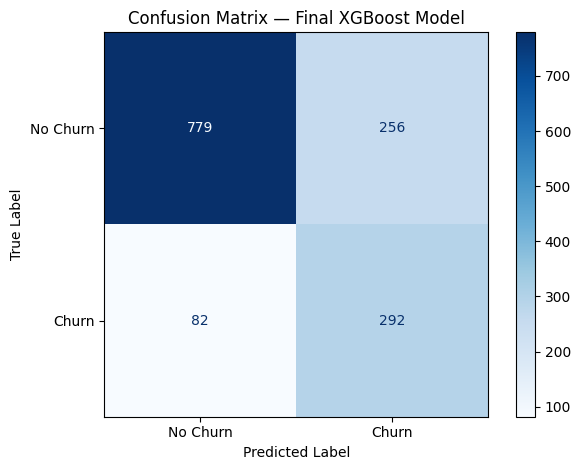

In [121]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix — Final XGBoost Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

### Final Test Interpretation

The final model achieves a ROC-AUC of 0.848 and Average Precision of 0.666 on the held-out test set, closely matching the performance observed during cross-validation.

Using the selected threshold of 0.30, the model identifies **292 of the 374 customers who actually churn**, corresponding to a recall of approximately **78%**.

The model generates 256 false-positive alerts, resulting in a precision of approximately 53%. This reflects the intentional retention-oriented strategy: accepting additional false positives in exchange for identifying a substantially larger proportion of customers at risk of leaving.

The similarity between cross-validation and test performance suggests that the modeling strategy generalizes reasonably well to unseen data.

## 10. Model Explainability

Understanding which customer characteristics influence the model is important for translating predictions into actionable business insights.

Feature importance from the final XGBoost model is analyzed to identify the variables that contribute most strongly to its predictions.

In [122]:
feature_names = best_xgb_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importances = best_xgb_model.named_steps[
    "classifier"
].feature_importances_

In [123]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
27,cat__Contract_Month-to-month,0.370781
7,cat__InternetService_Fiber optic,0.109194
9,cat__OnlineSecurity_No,0.065486
18,cat__TechSupport_No,0.059355
32,cat__PaymentMethod_Electronic check,0.035214
0,num__tenure,0.030532
29,cat__Contract_Two year,0.028592
5,cat__MultipleLines_Yes,0.023378
26,cat__StreamingMovies_Yes,0.021884
28,cat__Contract_One year,0.021330


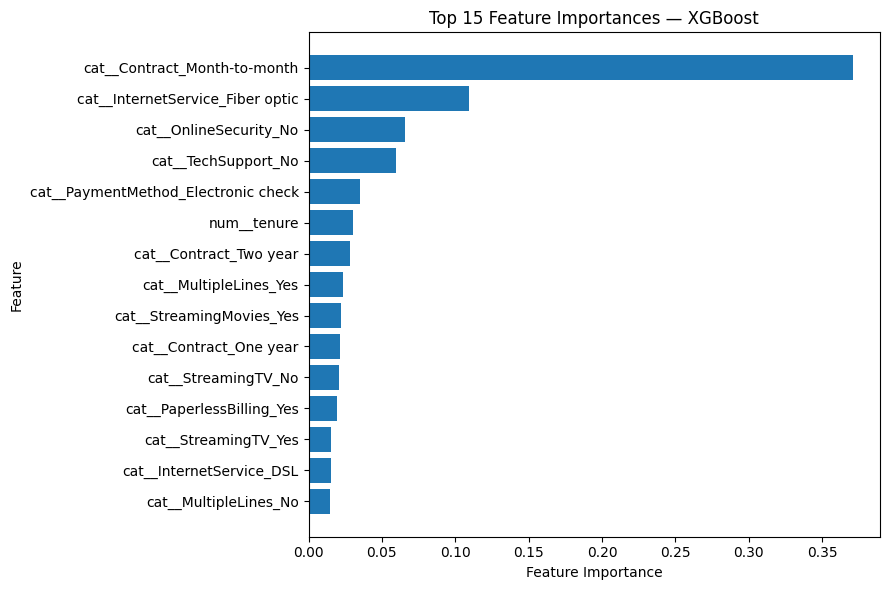

In [124]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The XGBoost feature importance analysis shows that contract type, particularly month-to-month contracts, plays an important role in the model's predictions.

Other relevant features include fiber optic internet service, lack of online security and technical support, electronic check payments, and customer tenure.

These findings are broadly consistent with the patterns identified during exploratory data analysis, where several of these customer characteristics were associated with higher observed churn rates.

However, feature importance represents predictive relevance within the model and should not be interpreted as evidence that these characteristics directly cause customer churn.

## 11. Conclusions and Business Recommendations

This project developed a machine learning approach for identifying customers at risk of churn and translating model predictions into a potential customer retention strategy.

### 11.1 Technical Conclusions

Several classification approaches were evaluated using stratified cross-validation, including Logistic Regression, Random Forest, and XGBoost.

The main technical conclusions are:

- Logistic Regression provided a strong baseline, achieving a mean ROC-AUC of 0.846 and Average Precision of 0.662.
- Random Forest did not improve upon Logistic Regression, showing that additional model complexity does not necessarily lead to better predictive performance.
- XGBoost achieved the strongest overall ranking performance. After hyperparameter tuning, it reached a mean cross-validation ROC-AUC of 0.851 and Average Precision of 0.673.
- Adjusting the classification threshold from 0.50 to 0.30 substantially increased the model's ability to detect churners.
- On the held-out test set, the final model achieved a ROC-AUC of 0.848, Average Precision of 0.666, and recall of 0.781.
- The similarity between cross-validation and test performance suggests that the final modeling strategy generalizes reasonably well to unseen customers.

### 11.2 Business Interpretation

The analysis identifies several customer characteristics that are particularly relevant for churn prediction.

Customers with month-to-month contracts represent an especially important segment for the model. Other relevant characteristics include fiber optic internet service, absence of online security or technical support, electronic check payments, and customer tenure.

These findings are consistent with the exploratory analysis, where month-to-month customers, customers without support-related services, and customers using electronic checks showed higher observed churn rates.

These relationships should be interpreted as predictive associations rather than causal effects.

### 11.3 Potential Retention Strategy

Rather than treating every customer equally, the model could be used to prioritize customers according to their predicted probability of churn.

Using the selected threshold of 0.30, the final model identified 292 of the 374 churners in the test set, corresponding to approximately 78% recall. This comes at the cost of additional false-positive alerts, which may be acceptable when the cost of a retention intervention is relatively low compared with the cost of losing a customer.

A potential retention workflow could therefore:

1. Generate churn probabilities for active customers.
2. Rank customers from highest to lowest predicted churn risk.
3. Prioritize high-risk customers for retention campaigns.
4. Combine model predictions with business constraints such as campaign capacity and intervention cost.
5. Monitor campaign outcomes and periodically retrain the model with new customer data.

### 11.4 Limitations

Several limitations should be considered when interpreting the results:

- The analysis is based on a single historical customer dataset, and performance may differ when applied to another company or customer population.
- The model identifies predictive associations but does not establish causal relationships between customer characteristics and churn.
- The selected threshold of 0.30 represents a retention-oriented scenario rather than a universally optimal decision threshold.
- A real deployment would require information about the financial cost of churn, retention campaigns, and false-positive interventions to determine the optimal business strategy.
- Model performance should be monitored over time because customer behavior and churn patterns may change.

### 11.5 Final Conclusion

The project demonstrates how exploratory data analysis, reproducible preprocessing, cross-validation, model comparison, hyperparameter tuning, and decision-threshold optimization can be combined to develop a practical churn prediction system.

The final XGBoost model provides useful discrimination between churners and non-churners while allowing the classification strategy to be adapted to a retention-oriented business objective.

Rather than replacing business decision-making, the model can serve as a prioritization tool to help retention teams focus their resources on customers with the highest predicted risk of churn.

## 12. Model Export

The final trained pipeline is saved together with the selected classification threshold so that it can be reused for future predictions without retraining the model.

In [125]:
import joblib

In [126]:
model_artifact = {
    "model": best_xgb_model,
    "threshold": final_threshold
}

joblib.dump(
    model_artifact,
    "../models/churn_xgboost_model.joblib"
)

['../models/churn_xgboost_model.joblib']

In [127]:
loaded_artifact = joblib.load(
    "../models/churn_xgboost_model.joblib"
)

loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["threshold"]

print("Saved threshold:", loaded_threshold)

Saved threshold: 0.3


In [128]:
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]

np.allclose(
    y_prob_final,
    loaded_probabilities
)

True